In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Sampling Setup

sample_rate = 5000 # hz, or frequency
duration = 1.0  # time range, 0 to 1

t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

In [4]:
# Signal Parameters + Damped Sinusoid Setup

A = 1.0 # Amplitude
tau = 0.15 # decay time constant
f = 300 # frequency in hertz

signal_clean = A * np.exp(-t / tau) * np.sin(2 * np.pi * f * t)

In [5]:
# Adding in Noise

noise_level = 0.05
noise = np.random.normal(0, noise_level, size=t.shape)
signal_noisy = signal_clean + noise

<function matplotlib.pyplot.show(close=None, block=None)>

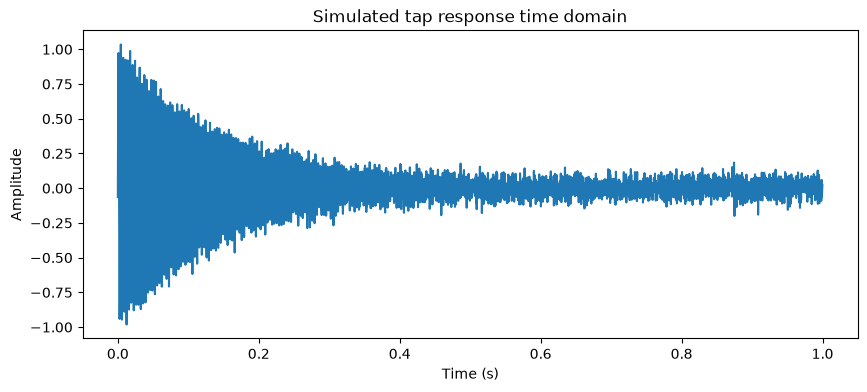

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(t, signal_noisy)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Simulated tap response time domain")
plt.show

In [7]:
N = len(signal_noisy)

fft_result = np.fft.fft(signal_noisy)
freqs = np.fft.fftfreq(N, d=1/sample_rate)

In [11]:
positive_mask = freqs > 0
freqs_pos = freqs[positive_mask]
magnitude = np.abs(fft_result[positive_mask])

<function matplotlib.pyplot.show(close=None, block=None)>

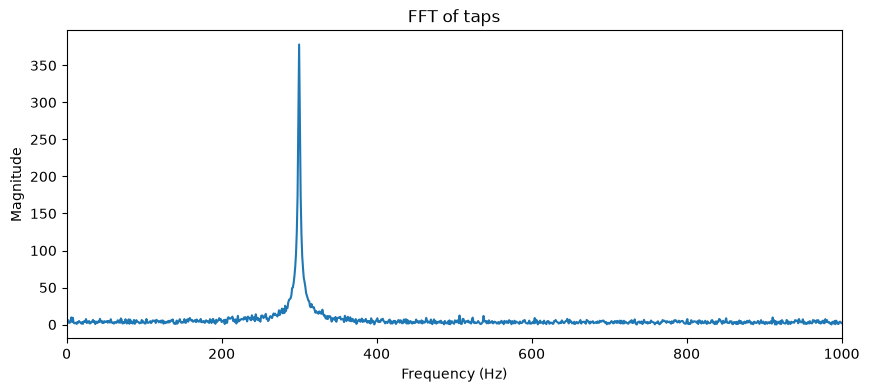

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(freqs_pos, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of taps")
plt.xlim(0, 1000)
plt.show

In [14]:
window_length = 250
hop_size = 125
final_start = 4750

spectrogram_columns = []

for start in range (0, final_start + 1, hop_size):
    chunk = signal_noisy[start : start + window_length]
    chunk_fft = np.fft.fft(chunk)
    spectrogram_columns.append(chunk_fft)